In [ ]:
!pip install ucimlrepo pandas numpy scikit-learn matplotlib seaborn

In [ ]:
!pip install xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [ ]:
# Fetch dataset from UCI
german_credit = fetch_ucirepo(id=144)

# Features
X = german_credit.data.features.copy()

# Target
y = german_credit.data.targets.copy()

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 20)
Target Shape: (1000, 1)


In [ ]:
print("\nFirst 5 rows:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature information:")
print(X.info())


First 5 rows:
  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   
3        A11          42        A32        A42        7882        A61   
4        A11          24        A33        A40        4870        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   
2        A74           2        A93        A101            3        A121   
3        A74           2        A93        A103            4        A122   
4        A73           3        A93        A101            4        A124   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0        

In [ ]:
print("\nTarget values:")
print(y.iloc[:, 0].value_counts())


Target values:
class
1    700
2    300
Name: count, dtype: int64


In [ ]:
y = y.iloc[:, 0]

print(y.unique())

[1 2]


In [ ]:
# Convert target:
# Good credit = 0
# Bad credit = 1

y = y.map({
    1: 0,
    2: 1
})

In [ ]:
print("\nEncoded target:")
print(y.value_counts())

print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)


Encoded target:
class
0    700
1    300
Name: count, dtype: int64

Target percentages:
class
0    70.0
1    30.0
Name: proportion, dtype: float64


In [ ]:
print("\nMissing values:")
print(X.isnull().sum())


Missing values:
Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
Attribute6     0
Attribute7     0
Attribute8     0
Attribute9     0
Attribute10    0
Attribute11    0
Attribute12    0
Attribute13    0
Attribute14    0
Attribute15    0
Attribute16    0
Attribute17    0
Attribute18    0
Attribute19    0
Attribute20    0
dtype: int64


In [ ]:
print("\nTotal missing values:")
print(X.isnull().sum().sum())


Total missing values:
0


**Identify the Numerical & Categorical Features**

In [ ]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute16', 'Attribute18']

Categorical features:
['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute9', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']


**Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 800
Testing samples : 200


**Preprocessing Pipelines**

In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [ ]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [ ]:
preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

**Algorithm 1 - LogisticRegression**

In [ ]:
lr_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])


**Hyperparameter Turning**

In [ ]:
param_grid_lr = {
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ]
}

**Cross Fold Validation**

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# ROC curve
grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Attribute2',
                                                                          'Attribute5',
                                                                          'Attribute8',
                                                                          'Attribute11',
                                                                          'Attribute13',
                                                                          'Attribute16',
                                                                          'Attribute18']),
                                                                        (...
                                                                          'Attribute4',
                                                                          'Attribute6',
                                                                          'Attribute7',
                                                                          'Attribute9',
                                                                          'Attribute10',
                                                                          'Attribute12',
                                                                          'Attribute14',
                                                                          'Attribute15',
                                                                          'Attribute17',
                                                                          'Attribute19',
                                                                          'Attribute20'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}


In [ ]:
print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_lr.best_score_, 4))


Best Cross-Validation ROC-AUC:
0.7838


In [ ]:
best_lr = grid_lr.best_estimator_

In [ ]:
y_pred_lr = best_lr.predict(X_test)

In [ ]:
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

roc_auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)


       LOGISTIC REGRESSION
Accuracy  : 0.7900
Precision : 0.7143
Recall    : 0.5000
F1-Score  : 0.5882
ROC-AUC   : 0.8095

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.81      0.91      0.86       140
  Bad Credit       0.71      0.50      0.59        60

    accuracy                           0.79       200
   macro avg       0.76      0.71      0.72       200
weighted avg       0.78      0.79      0.78       200



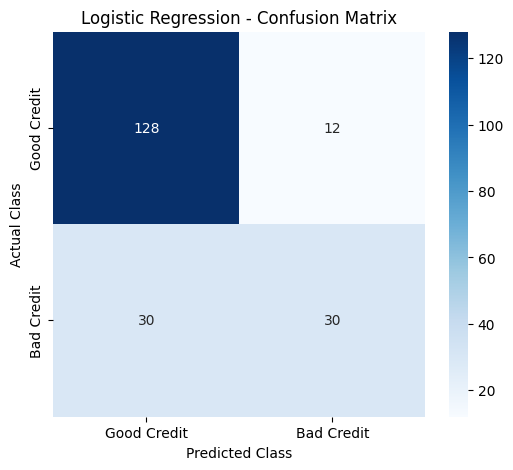

<Figure size 700x500 with 0 Axes>

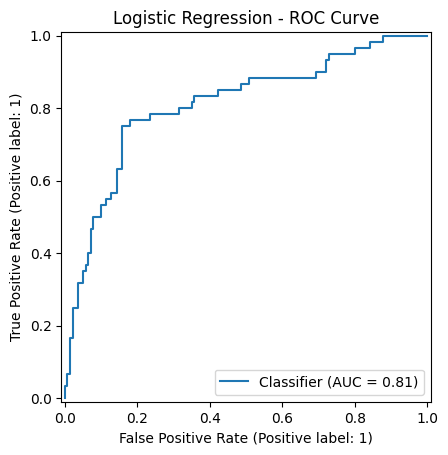

In [ ]:
print("\n===================================")
print("       LOGISTIC REGRESSION")
print("===================================")

print(
    f"Accuracy  : {accuracy_lr:.4f}"
)

print(
    f"Precision : {precision_lr:.4f}"
)

print(
    f"Recall    : {recall_lr:.4f}"
)

print(
    f"F1-Score  : {f1_lr:.4f}"
)

print(
    f"ROC-AUC   : {roc_auc_lr:.4f}"
)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ],
        zero_division=0
    )
)
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Good Credit",
        "Bad Credit"
    ],
    yticklabels=[
        "Good Credit",
        "Bad Credit"
    ]
)

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title(
    "Logistic Regression - ROC Curve"
)

plt.show()

**Results**

In [ ]:
lr_results = {
    "Algorithm": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-Score": f1_lr,
    "ROC-AUC": roc_auc_lr
}

print(lr_results)
results_df = pd.DataFrame(
    [lr_results]
)

results_df

{'Algorithm': 'Logistic Regression', 'Accuracy': 0.79, 'Precision': 0.7142857142857143, 'Recall': 0.5, 'F1-Score': 0.5882352941176471, 'ROC-AUC': np.float64(0.8095238095238096)}


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.79,0.714286,0.5,0.588235,0.809524


**Algorithm 2 - Decision Tree**

Fitting 5 folds for each of 135 candidates, totalling 675 fits

Best Parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best Cross-Validation ROC-AUC: 0.727

          DECISION TREE
Accuracy  : 0.6700
Precision : 0.4516
Recall    : 0.4667
F1-Score  : 0.4590
ROC-AUC   : 0.6675

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.77      0.76      0.76       140
  Bad Credit       0.45      0.47      0.46        60

    accuracy                           0.67       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.67      0.67      0.67       200



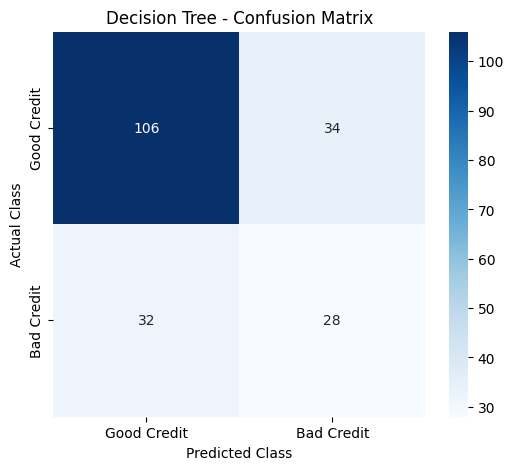

<Figure size 700x500 with 0 Axes>

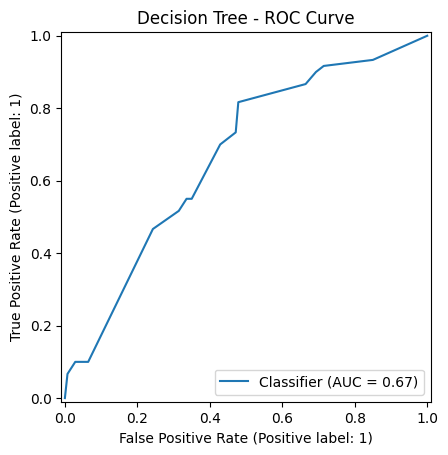


Final Decision Tree Result:
       Algorithm  Accuracy  Precision    Recall  F1-Score  ROC-AUC
0  Decision Tree      0.67   0.451613  0.466667  0.459016   0.6675


In [ ]:

# ============================================================
# ALGORITHM 2: DECISION TREE
# DATASET: UCI STATLOG GERMAN CREDIT DATA
# ============================================================

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. DECISION TREE PIPELINE
# ============================================================

dt_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


# ============================================================
# 2. HYPERPARAMETER GRID
# ============================================================

param_grid_dt = {

    "classifier__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "classifier__max_depth": [
        3,
        5,
        7,
        10,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        5
    ]
}


# ============================================================
# 3. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. GRID SEARCH
# ============================================================

grid_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(
    X_train,
    y_train
)


# ============================================================
# 5. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")
print(grid_dt.best_params_)

print(
    "\nBest Cross-Validation ROC-AUC:",
    round(grid_dt.best_score_, 4)
)


# ============================================================
# 6. BEST MODEL
# ============================================================

best_dt = grid_dt.best_estimator_


# ============================================================
# 7. PREDICTIONS
# ============================================================

y_pred_dt = best_dt.predict(X_test)

y_prob_dt = best_dt.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 8. METRICS
# ============================================================

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)


# ============================================================
# 9. RESULTS
# ============================================================

print("\n===================================")
print("          DECISION TREE")
print("===================================")

print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")
print(f"ROC-AUC   : {roc_auc_dt:.4f}")


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ],
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Good Credit",
        "Bad Credit"
    ],
    yticklabels=[
        "Good Credit",
        "Bad Credit"
    ]
)

plt.title(
    "Decision Tree - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


# ============================================================
# 12. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt
)

plt.title(
    "Decision Tree - ROC Curve"
)

plt.show()


# ============================================================
# 13. STORE RESULTS
# ============================================================

dt_results = {
    "Algorithm": "Decision Tree",
    "Accuracy": accuracy_dt,
    "Precision": precision_dt,
    "Recall": recall_dt,
    "F1-Score": f1_dt,
    "ROC-AUC": roc_auc_dt
}

dt_results_df = pd.DataFrame(
    [dt_results]
)

print("\nFinal Decision Tree Result:")
print(dt_results_df)

**Algorithm 3 - RandomForest**

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validation ROC-AUC: 0.7951

          RANDOM FOREST
Accuracy  : 0.7700
Precision : 0.6944
Recall    : 0.4167
F1-Score  : 0.5208
ROC-AUC   : 0.8038

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.79      0.92      0.85       140
  Bad Credit       0.69      0.42      0.52        60

    accuracy                           0.77       200
   macro avg       0.74      0.67      0.68       200
weighted avg       0.76      0.77      0.75       200



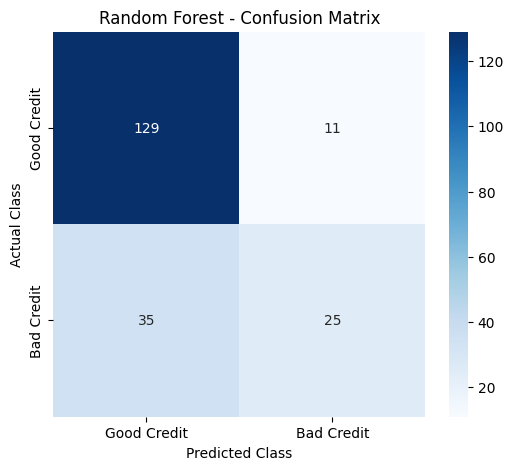

<Figure size 700x500 with 0 Axes>

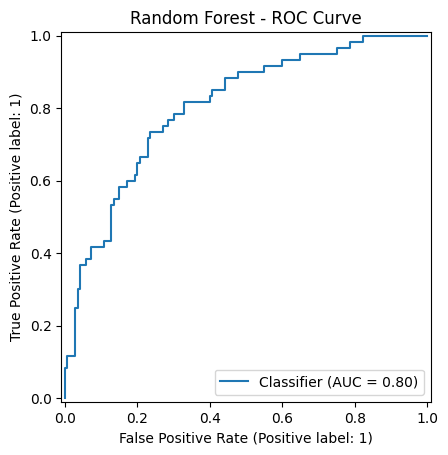


Top 15 Important Features:
                          Feature  Importance
1           numerical__Attribute5    0.103124
0           numerical__Attribute2    0.079626
10    categorical__Attribute1_A14    0.073176
4          numerical__Attribute13    0.068703
7     categorical__Attribute1_A11    0.044840
2           numerical__Attribute8    0.031975
26    categorical__Attribute6_A61    0.025359
3          numerical__Attribute11    0.024730
15    categorical__Attribute3_A34    0.022578
47  categorical__Attribute14_A141    0.021492
8     categorical__Attribute1_A12    0.020279
32    categorical__Attribute7_A72    0.019543
49  categorical__Attribute14_A143    0.017212
46  categorical__Attribute12_A124    0.017157
30    categorical__Attribute6_A65    0.016866


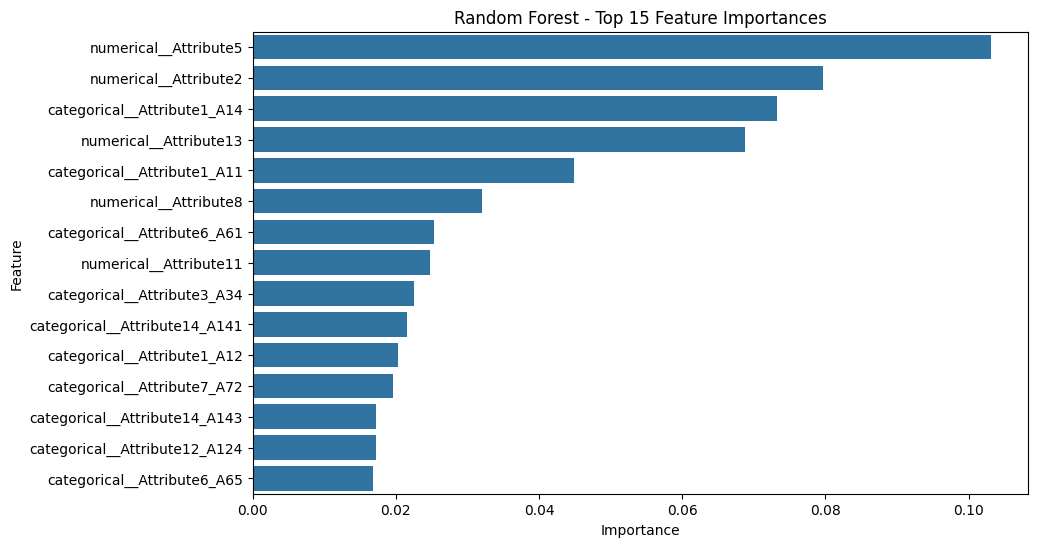


Final Random Forest Result:
       Algorithm  Accuracy  Precision    Recall  F1-Score  ROC-AUC
0  Random Forest      0.77   0.694444  0.416667  0.520833  0.80381


In [ ]:
# ============================================================
# ALGORITHM 3: RANDOM FOREST
# DATASET: UCI STATLOG GERMAN CREDIT DATA
# ============================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. RANDOM FOREST PIPELINE
# ============================================================

rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])


# ============================================================
# 2. HYPERPARAMETER GRID
# ============================================================

param_grid_rf = {

    "classifier__n_estimators": [
        100,
        200
    ],

    "classifier__max_depth": [
        5,
        10,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5
    ],

    "classifier__min_samples_leaf": [
        1,
        2
    ],

    "classifier__max_features": [
        "sqrt"
    ]
}


# ============================================================
# 3. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. GRID SEARCH
# ============================================================

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(
    X_train,
    y_train
)


# ============================================================
# 5. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")
print(grid_rf.best_params_)

print(
    "\nBest Cross-Validation ROC-AUC:",
    round(grid_rf.best_score_, 4)
)


# ============================================================
# 6. BEST MODEL
# ============================================================

best_rf = grid_rf.best_estimator_


# ============================================================
# 7. PREDICTIONS
# ============================================================

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 8. METRICS
# ============================================================

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)


# ============================================================
# 9. RESULTS
# ============================================================

print("\n===================================")
print("          RANDOM FOREST")
print("===================================")

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ],
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Good Credit",
        "Bad Credit"
    ],
    yticklabels=[
        "Good Credit",
        "Bad Credit"
    ]
)

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


# ============================================================
# 12. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title(
    "Random Forest - ROC Curve"
)

plt.show()


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

fitted_preprocessor = (
    best_rf.named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importance_values = (
    best_rf
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_rf = (
    feature_importance_rf
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nTop 15 Important Features:")
print(
    feature_importance_rf.head(15)
)


# ============================================================
# 14. FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (
    feature_importance_rf
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest - Top 15 Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()


# ============================================================
# 15. STORE RESULTS
# ============================================================

rf_results = {
    "Algorithm": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-Score": f1_rf,
    "ROC-AUC": roc_auc_rf
}

rf_results_df = pd.DataFrame(
    [rf_results]
)

print("\nFinal Random Forest Result:")
print(rf_results_df)

**Algorithm 4 - SVM(Support Vector Machine)**

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best Parameters:
{'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

Best Cross-Validation ROC-AUC: 0.7909

       SUPPORT VECTOR MACHINE
Accuracy  : 0.7900
Precision : 0.7250
Recall    : 0.4833
F1-Score  : 0.5800
ROC-AUC   : 0.7960

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.81      0.92      0.86       140
  Bad Credit       0.72      0.48      0.58        60

    accuracy                           0.79       200
   macro avg       0.77      0.70      0.72       200
weighted avg       0.78      0.79      0.78       200



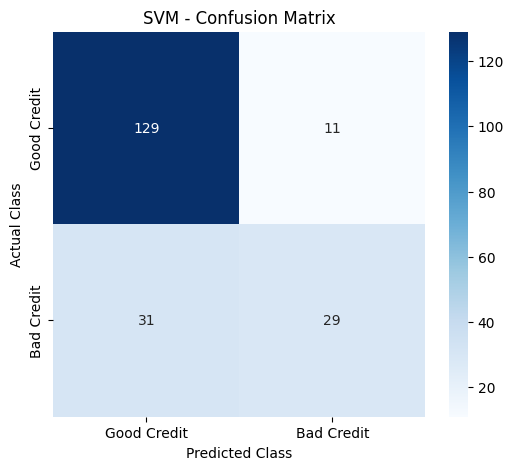

<Figure size 700x500 with 0 Axes>

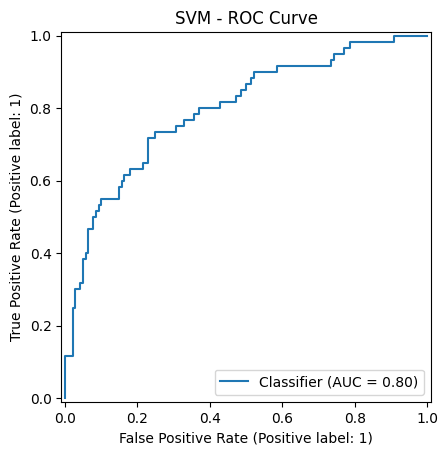


Final SVM Result:
  Algorithm  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0       SVM      0.79      0.725  0.483333      0.58  0.795952


In [ ]:
# ============================================================
# ALGORITHM 4: SUPPORT VECTOR MACHINE
# DATASET: UCI STATLOG GERMAN CREDIT DATA
# ============================================================

from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. SVM PIPELINE
# ============================================================

svm_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        SVC(
            probability=True,
            random_state=42
        )
    )
])


# ============================================================
# 2. HYPERPARAMETER GRID
# ============================================================

param_grid_svm = [

    {
        "classifier__kernel": ["linear"],

        "classifier__C": [
            0.1,
            1,
            10
        ]
    },

    {
        "classifier__kernel": ["rbf"],

        "classifier__C": [
            0.1,
            1,
            10
        ],

        "classifier__gamma": [
            "scale",
            "auto"
        ]
    }
]


# ============================================================
# 3. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. GRID SEARCH
# ============================================================

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(
    X_train,
    y_train
)


# ============================================================
# 5. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")
print(grid_svm.best_params_)

print(
    "\nBest Cross-Validation ROC-AUC:",
    round(grid_svm.best_score_, 4)
)


# ============================================================
# 6. BEST MODEL
# ============================================================

best_svm = grid_svm.best_estimator_


# ============================================================
# 7. PREDICTIONS
# ============================================================

y_pred_svm = best_svm.predict(
    X_test
)

y_prob_svm = best_svm.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 8. METRICS
# ============================================================

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

roc_auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)


# ============================================================
# 9. RESULTS
# ============================================================

print("\n===================================")
print("       SUPPORT VECTOR MACHINE")
print("===================================")

print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")
print(f"ROC-AUC   : {roc_auc_svm:.4f}")


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ],
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Good Credit",
        "Bad Credit"
    ],
    yticklabels=[
        "Good Credit",
        "Bad Credit"
    ]
)

plt.title(
    "SVM - Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


# ============================================================
# 12. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm
)

plt.title(
    "SVM - ROC Curve"
)

plt.show()


# ============================================================
# 13. STORE RESULTS
# ============================================================

svm_results = {
    "Algorithm": "SVM",
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1-Score": f1_svm,
    "ROC-AUC": roc_auc_svm
}

svm_results_df = pd.DataFrame(
    [svm_results]
)

print("\nFinal SVM Result:")
print(svm_results_df)

**Algorithm 5 - XGBoost**

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGBoost Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.7887

        XGBOOST RESULTS
Accuracy : 0.75
Precision: 0.6087
Recall   : 0.4667
F1-Score : 0.5283
ROC-AUC  : 0.7873

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.79      0.87      0.83       140
  Bad Credit       0.61      0.47      0.53        60

    accuracy                           0.75       200
   macro avg       0.70      0.67      0.68       200
weighted avg       0.74      0.75      0.74       200



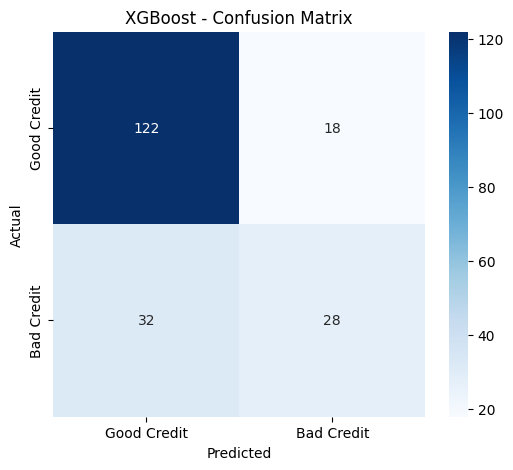

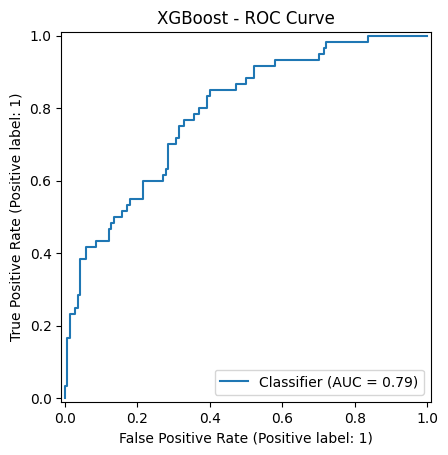


    MODEL COMPARISON SO FAR
          Algorithm  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.79     0.7143  0.5000    0.5882   0.8095
      Decision Tree      0.67     0.4516  0.4667    0.4590   0.6675
      Random Forest      0.77     0.6944  0.4167    0.5208   0.8038
                SVM      0.79     0.7250  0.4833    0.5800   0.7960
            XGBoost      0.75     0.6087  0.4667    0.5283   0.7873


In [ ]:
# ============================================================
# XGBOOST - CREDIT RISK CLASSIFICATION
# ============================================================

# Step 1: Install XGBoost
!pip install xgboost

# Step 2: Import XGBoost
from xgboost import XGBClassifier

# ============================================================
# Step 3: Create XGBoost Pipeline
# ============================================================

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# ============================================================
# Step 4: Define Hyperparameter Grid
# ============================================================

param_grid_xgb = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1]
}

# ============================================================
# Step 5: Grid Search with 5-Fold Stratified CV
# ============================================================

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

# ============================================================
# Step 6: Display Best Parameters
# ============================================================

print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_xgb.best_score_, 4))

# ============================================================
# Step 7: Get Best Model
# ============================================================

best_xgb = grid_xgb.best_estimator_

# ============================================================
# Step 8: Predictions
# ============================================================

y_pred_xgb = best_xgb.predict(X_test)

# Probability of Bad Credit (class = 1)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# ============================================================
# Step 9: Calculate Evaluation Metrics
# ============================================================

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

# ============================================================
# Step 10: Display Results
# ============================================================

print("\n========================================")
print("        XGBOOST RESULTS")
print("========================================")

print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1-Score :", round(f1_xgb, 4))
print("ROC-AUC  :", round(roc_auc_xgb, 4))

# ============================================================
# Step 11: Classification Report
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ]
    )
)

# ============================================================
# Step 12: Confusion Matrix
# ============================================================

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

plt.show()

# ============================================================
# Step 13: ROC Curve
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost - ROC Curve")
plt.show()

# ============================================================
# Step 14: Store XGBoost Results
# ============================================================

xgb_results = {
    "Algorithm": "XGBoost",
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1-Score": f1_xgb,
    "ROC-AUC": roc_auc_xgb
}

# ============================================================
# Step 15: Compare All 5 Completed Algorithms
# ============================================================

all_results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    svm_results,
    xgb_results
])

all_results = all_results.round(4)

print("\n========================================")
print("    MODEL COMPARISON SO FAR")
print("========================================")

print(all_results.to_string(index=False))

**Algorithm 6 - LightGBM**

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best LightGBM Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': -1, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31}

Best Cross-Validation ROC-AUC:
0.7928

        LIGHTGBM RESULTS
Accuracy : 0.73
Precision: 0.5682
Recall   : 0.4167
F1-Score : 0.4808
ROC-AUC  : 0.764

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.78      0.86      0.82       140
  Bad Credit       0.57      0.42      0.48        60

    accuracy                           0.73       200
   macro avg       0.67      0.64      0.65       200
weighted avg       0.71      0.73      0.72       200



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


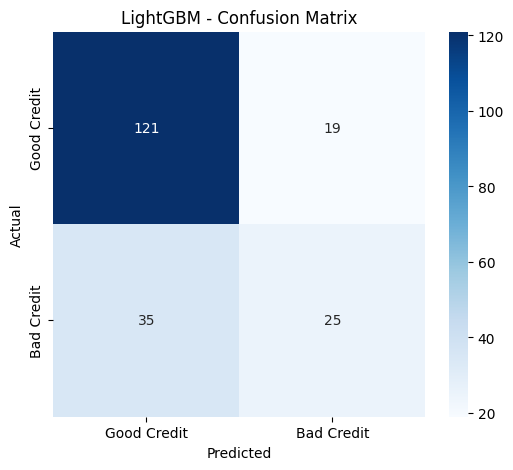

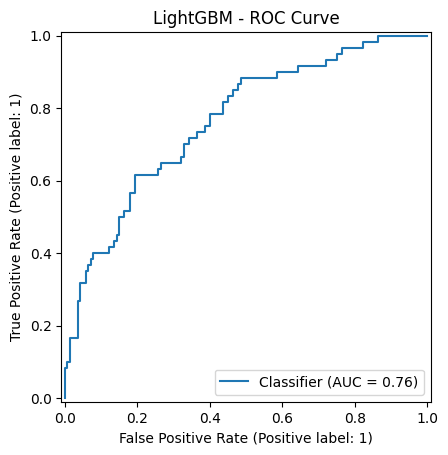


       FINAL MODEL COMPARISON
          Algorithm  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.79     0.7143  0.5000    0.5882   0.8095
      Decision Tree      0.67     0.4516  0.4667    0.4590   0.6675
      Random Forest      0.77     0.6944  0.4167    0.5208   0.8038
                SVM      0.79     0.7250  0.4833    0.5800   0.7960
            XGBoost      0.75     0.6087  0.4667    0.5283   0.7873
           LightGBM      0.73     0.5682  0.4167    0.4808   0.7640


In [ ]:
# ============================================================
# LIGHTGBM - CREDIT RISK CLASSIFICATION
# ============================================================

# Step 1: Install LightGBM
!pip install lightgbm

# Step 2: Import LightGBM
from lightgbm import LGBMClassifier

# ============================================================
# Step 3: Create LightGBM Pipeline
# ============================================================

lgbm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

# ============================================================
# Step 4: Define Hyperparameter Grid
# ============================================================

param_grid_lgbm = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [-1, 5],
    "classifier__num_leaves": [15, 31]
}

# ============================================================
# Step 5: Grid Search with 5-Fold Stratified CV
# ============================================================

grid_lgbm = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid_lgbm,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lgbm.fit(X_train, y_train)

# ============================================================
# Step 6: Display Best Parameters
# ============================================================

print("Best LightGBM Parameters:")
print(grid_lgbm.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(grid_lgbm.best_score_, 4))

# ============================================================
# Step 7: Get Best Model
# ============================================================

best_lgbm = grid_lgbm.best_estimator_

# ============================================================
# Step 8: Generate Predictions
# ============================================================

y_pred_lgbm = best_lgbm.predict(X_test)

# Probability of Bad Credit (class = 1)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

# ============================================================
# Step 9: Calculate Evaluation Metrics
# ============================================================

accuracy_lgbm = accuracy_score(
    y_test,
    y_pred_lgbm
)

precision_lgbm = precision_score(
    y_test,
    y_pred_lgbm,
    zero_division=0
)

recall_lgbm = recall_score(
    y_test,
    y_pred_lgbm,
    zero_division=0
)

f1_lgbm = f1_score(
    y_test,
    y_pred_lgbm,
    zero_division=0
)

roc_auc_lgbm = roc_auc_score(
    y_test,
    y_prob_lgbm
)

# ============================================================
# Step 10: Display Results
# ============================================================

print("\n========================================")
print("        LIGHTGBM RESULTS")
print("========================================")

print("Accuracy :", round(accuracy_lgbm, 4))
print("Precision:", round(precision_lgbm, 4))
print("Recall   :", round(recall_lgbm, 4))
print("F1-Score :", round(f1_lgbm, 4))
print("ROC-AUC  :", round(roc_auc_lgbm, 4))

# ============================================================
# Step 11: Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lgbm,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ]
    )
)

# ============================================================
# Step 12: Confusion Matrix
# ============================================================

cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Good Credit",
        "Bad Credit"
    ],
    yticklabels=[
        "Good Credit",
        "Bad Credit"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM - Confusion Matrix")

plt.show()

# ============================================================
# Step 13: ROC Curve
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lgbm
)

plt.title("LightGBM - ROC Curve")
plt.show()

# ============================================================
# Step 14: Store LightGBM Results
# ============================================================

lgbm_results = {
    "Algorithm": "LightGBM",
    "Accuracy": accuracy_lgbm,
    "Precision": precision_lgbm,
    "Recall": recall_lgbm,
    "F1-Score": f1_lgbm,
    "ROC-AUC": roc_auc_lgbm
}

# ============================================================
# Step 15: Final Six-Model Comparison
# ============================================================

all_results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    svm_results,
    xgb_results,
    lgbm_results
])

all_results = all_results.round(4)

print("\n========================================")
print("       FINAL MODEL COMPARISON")
print("========================================")

print(all_results.to_string(index=False))

**Final Performance Research**

In [ ]:
# ============================================================
# FINAL PERFORMANCE COMPARISON
# ============================================================

all_results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    svm_results,
    xgb_results,
    lgbm_results
])

all_results = all_results.round(4)

print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(all_results.to_string(index=False))

FINAL MODEL PERFORMANCE
          Algorithm  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.79     0.7143  0.5000    0.5882   0.8095
      Decision Tree      0.67     0.4516  0.4667    0.4590   0.6675
      Random Forest      0.77     0.6944  0.4167    0.5208   0.8038
                SVM      0.79     0.7250  0.4833    0.5800   0.7960
            XGBoost      0.75     0.6087  0.4667    0.5283   0.7873
           LightGBM      0.73     0.5682  0.4167    0.4808   0.7640


In [ ]:
all_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


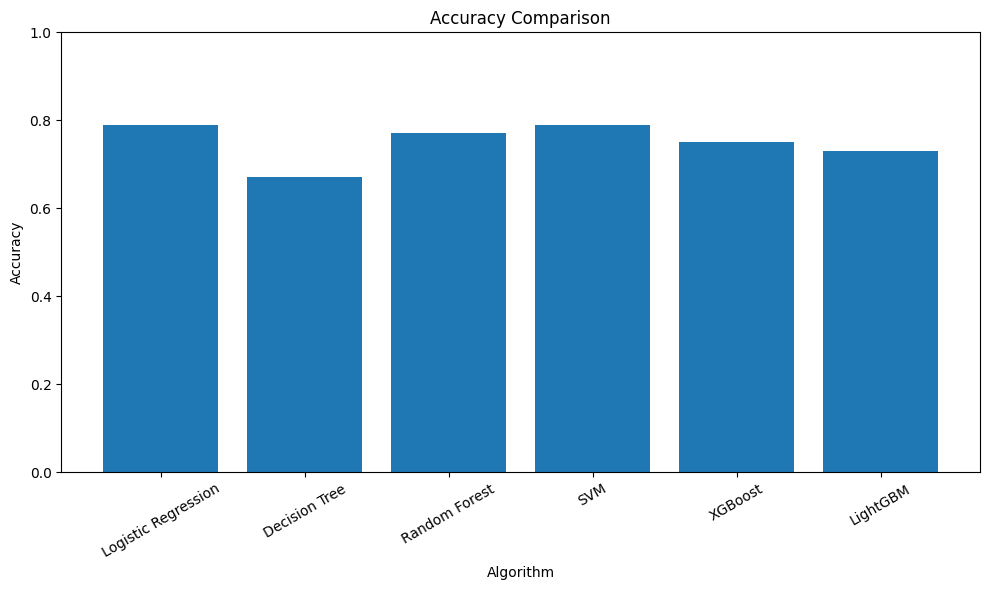

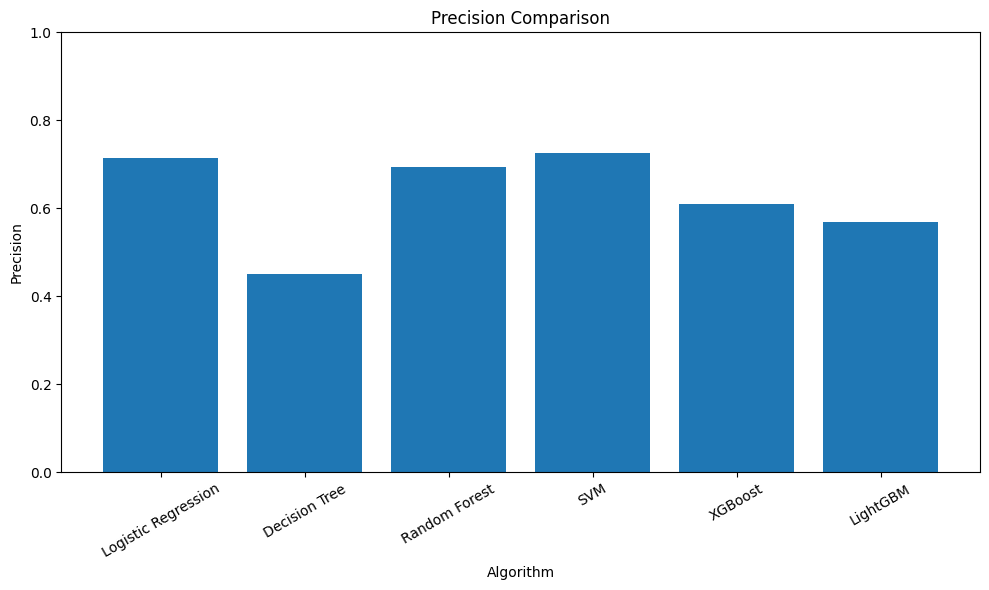

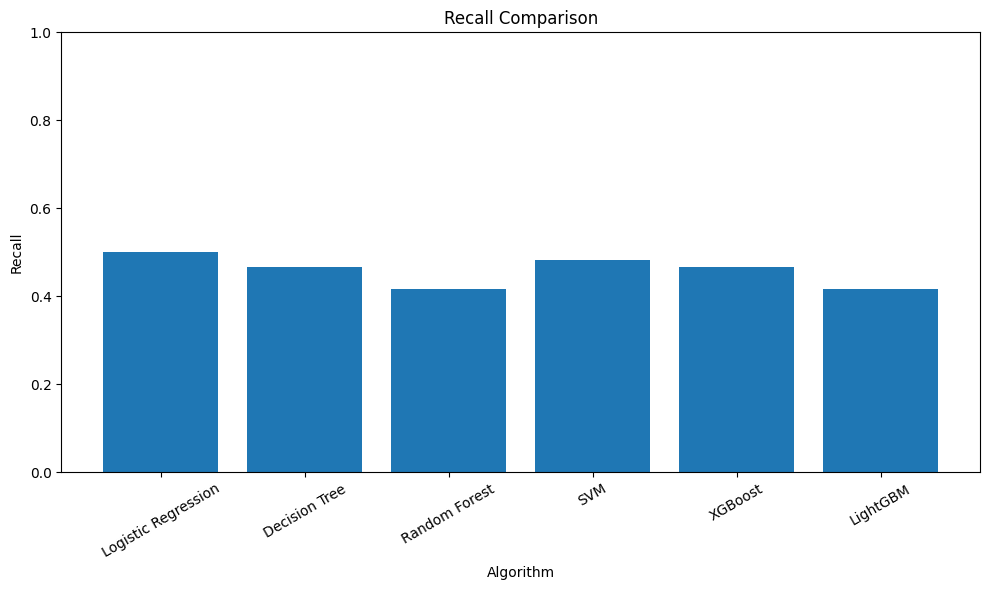

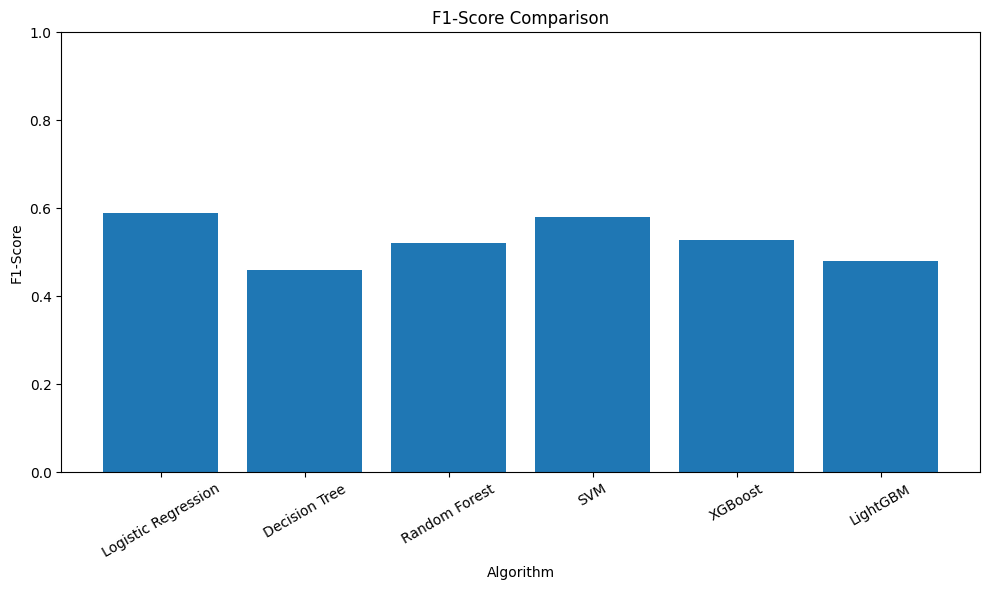

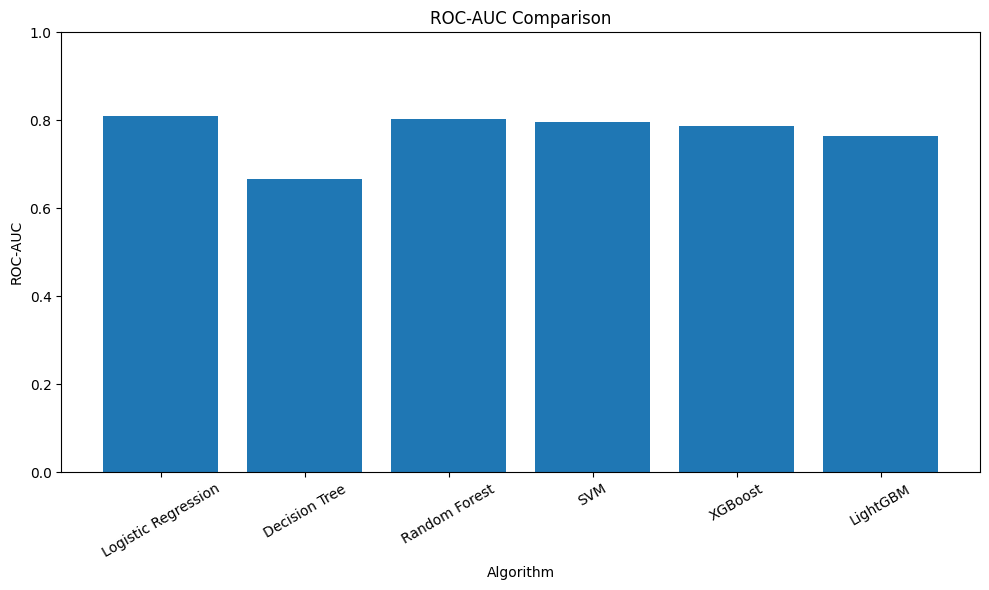

In [ ]:
# ============================================================
# METRIC COMPARISON
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

for metric in metrics:

    plt.figure(figsize=(10, 6))

    plt.bar(
        all_results["Algorithm"],
        all_results[metric]
    )

    plt.xlabel("Algorithm")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")

    plt.xticks(rotation=30)

    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

**ROC curve comparsion**

<Figure size 1000x700 with 0 Axes>

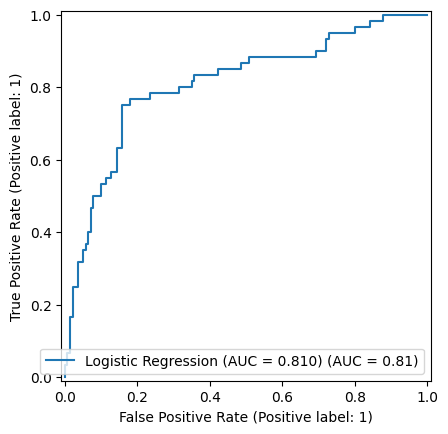

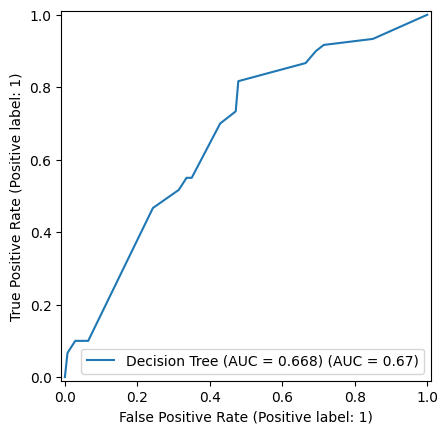

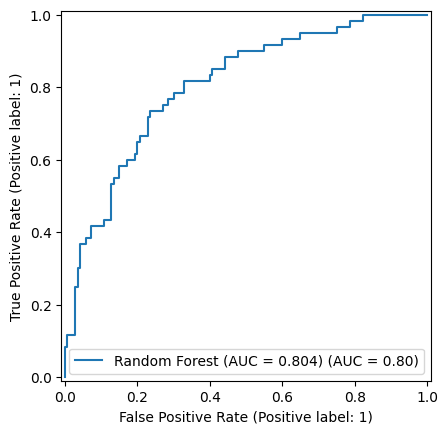

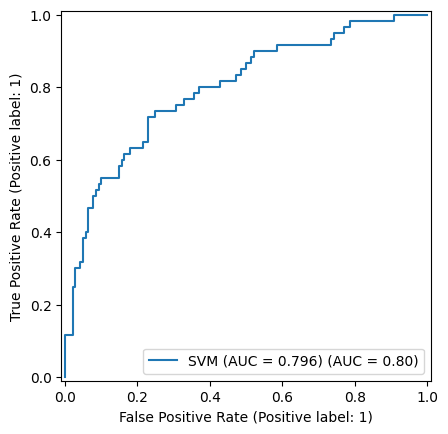

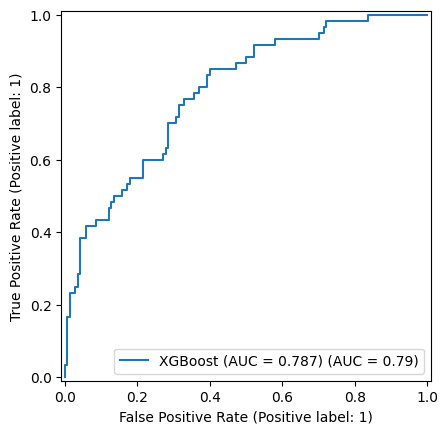

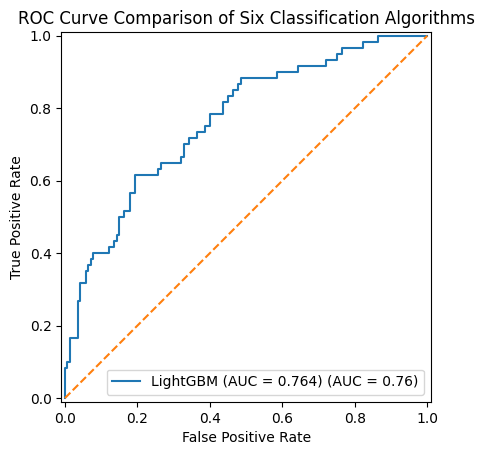

In [ ]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(10, 7))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm,
    name=f"SVM (AUC = {roc_auc_svm:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name=f"XGBoost (AUC = {roc_auc_xgb:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lgbm,
    name=f"LightGBM (AUC = {roc_auc_lgbm:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Six Classification Algorithms")

plt.show()

**Confusion Matricx**

In [ ]:
# ============================================================
# CONFUSION MATRIX DATA
# ============================================================

confusion_matrices = {
    "Logistic Regression": confusion_matrix(y_test, y_pred_lr),
    "Decision Tree": confusion_matrix(y_test, y_pred_dt),
    "Random Forest": confusion_matrix(y_test, y_pred_rf),
    "SVM": confusion_matrix(y_test, y_pred_svm),
    "XGBoost": confusion_matrix(y_test, y_pred_xgb),
    "LightGBM": confusion_matrix(y_test, y_pred_lgbm)
}

for model_name, cm in confusion_matrices.items():

    print("\n", model_name)
    print(cm)


 Logistic Regression
[[128  12]
 [ 30  30]]

 Decision Tree
[[106  34]
 [ 32  28]]

 Random Forest
[[129  11]
 [ 35  25]]

 SVM
[[129  11]
 [ 31  29]]

 XGBoost
[[122  18]
 [ 32  28]]

 LightGBM
[[121  19]
 [ 35  25]]


**Cross Validation Analysis**

In [ ]:
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV ROC-AUC:")
print(lr_cv_scores)

print("Mean:", lr_cv_scores.mean())
print("Std :", lr_cv_scores.std())

Logistic Regression CV ROC-AUC:
[0.82384673 0.81994048 0.78627232 0.68712798 0.80189732]
Mean: 0.7838169642857145
Std : 0.05017764136042811
